![Document anonymization](assets/headers/document-anonymization.jpg)

# 01. Document anonymization

We take a two-page customer record in PDF form, find the personal data on it and replace each value
with a realistic fake of the same type. The labels and layout stay where they were, so the document
is still readable. PyMuPDF reads and edits the PDF, Presidio finds the sensitive values and Faker
makes the replacements.

**Code co-created by:** Ülkü Tuncer Küçüktaş, Simge Danışoğlu, Tolga Turan, Gizem Acer

## Setup

Tested with Python 3.11. The next cell installs the package versions used in this notebook, including
the small English spaCy model that Presidio uses to recognize names, places and dates.

In [1]:
%pip install --quiet numpy==1.26.4 pandas==2.2.3 matplotlib==3.9.4 pymupdf==1.25.5 \
    presidio-analyzer==2.2.358 spacy==3.7.5 Faker==37.1.0 \
    https://github.com/explosion/spacy-models/releases/download/en_core_web_sm-3.7.1/en_core_web_sm-3.7.1-py3-none-any.whl

Note: you may need to restart the kernel to use updated packages.


In [2]:
from datetime import date
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymupdf
from faker import Faker
from matplotlib.colors import to_rgb
from matplotlib.patches import Patch, Rectangle
from presidio_analyzer import AnalyzerEngine, Pattern, PatternRecognizer
from presidio_analyzer.nlp_engine import NlpEngineProvider

# Colours used in the figures
NAVY, BLUE, TEAL, GOLD, RED = "#1C3076", "#3457A6", "#168A88", "#C58A00", "#B53B4A"
plt.rcParams.update({"figure.dpi": 120, "font.size": 11,
                     "axes.spines.top": False, "axes.spines.right": False})

## 1. A PDF with known personal data

We build the input ourselves, so we know every value that has to disappear. All people and numbers
below are made up. The second page repeats the name, email and member ID. A good replacement keeps
them consistent: the same person on page 1 and page 2 must get the same fake name.

In [3]:
PAGES = [
    [("Name", "Daniel Foster"),
     ("Email", "daniel.foster@example.com"),
     ("Phone", "(415) 555-0142"),
     ("Social Security Number", "534-21-9087"),
     ("Credit Card", "4111 1111 1111 1111"),
     ("IP Address", "192.168.24.17"),
     ("IBAN", "GB29 NWBK 6016 1331 9268 19"),
     ("Member ID", "ACT-778215"),
     ("Signup Date", "March 3, 2024")],
    [("Name", "Daniel Foster"),
     ("Email", "daniel.foster@example.com"),
     ("Member ID", "ACT-778215"),
     ("Address", "14 Example Road, Boston, MA 02108")],
]

OUT_DIR = Path("generated/01_document_anonymization")
OUT_DIR.mkdir(parents=True, exist_ok=True)
ORIGINAL_PDF = OUT_DIR / "record_original.pdf"
REPLACED_PDF = OUT_DIR / "record_replaced.pdf"
FONT_SIZE = 11

with pymupdf.open() as doc:
    for page_no, fields in enumerate(PAGES, 1):
        page = doc.new_page(width=660, height=500)
        page.draw_rect(pymupdf.Rect(0, 0, 660, 14), color=None, fill=to_rgb(NAVY))
        page.insert_text((48, 58), "ACME CLOUD", fontsize=19, fontname="hebo", color=to_rgb(NAVY))
        page.insert_text((48, 84), "Customer account record", fontsize=12)
        for row, (label, value) in enumerate(fields):
            y = 130 + 32 * row
            page.insert_text((48, y), label + ":", fontsize=FONT_SIZE)
            page.insert_text((245, y), value, fontsize=FONT_SIZE)
        page.insert_text((48, 476), f"Page {page_no} of {len(PAGES)}", fontsize=9)

    # Exported files often carry the customer's name in their properties as well
    doc.set_metadata({"title": "Account record for Daniel Foster"})
    doc.save(ORIGINAL_PDF)

print("Saved", ORIGINAL_PDF)

Saved generated/01_document_anonymization/record_original.pdf


## 2. What Presidio finds on its own

Presidio works on plain text, so we first pull the text out of each page. This is what it sees for
page 2: labels and values on separate lines, with no positions.

In [4]:
with pymupdf.open(ORIGINAL_PDF) as doc:
    page_texts = [page.get_text() for page in doc]

print(page_texts[1])

ACME CLOUD
Customer account record
Name:
Daniel Foster
Email:
daniel.foster@example.com
Member ID:
ACT-778215
Address:
14 Example Road, Boston, MA 02108
Page 2 of 2



Presidio's built-in recognizers use patterns and checksums for emails, phone numbers, SSNs, card
numbers, IP addresses and IBANs, and a spaCy language model for names, places and dates. We ask only
for the entity types this form can contain.

In [5]:
nlp_engine = NlpEngineProvider(nlp_configuration={
    "nlp_engine_name": "spacy",
    "models": [{"lang_code": "en", "model_name": "en_core_web_sm"}],
}).create_engine()
analyzer = AnalyzerEngine(nlp_engine=nlp_engine)

ENTITIES = ["PERSON", "EMAIL_ADDRESS", "PHONE_NUMBER", "US_SSN", "CREDIT_CARD",
            "IP_ADDRESS", "IBAN_CODE", "DATE_TIME", "LOCATION"]

rows = []
for page_no, text in enumerate(page_texts, 1):
    hits = analyzer.analyze(text, language="en", entities=ENTITIES)
    for hit in sorted(hits, key=lambda h: h.start):
        rows.append({"page": page_no, "entity": hit.entity_type,
                     "value": text[hit.start:hit.end].strip(), "score": hit.score})
pd.DataFrame(rows)

,page,entity,value,score
0,1,PERSON,Daniel Foster,0.85
1,1,EMAIL_ADDRESS,daniel.foster@example.com,1.00
2,1,PHONE_NUMBER,(415) 555-0142,0.75
3,1,US_SSN,534-21-9087,0.85
4,1,CREDIT_CARD,4111 1111 1111 1111,1.00
5,1,DATE_TIME,4111 1111 1111 1111,0.85
6,1,IP_ADDRESS,192.168.24.17,0.95
7,1,PHONE_NUMBER,192.168.24.17,0.40
8,1,IBAN_CODE,GB29 NWBK 6016 1331 9268 19,1.00
9,1,PERSON,NWBK,0.85


Most fields are found, but three things go wrong:

- The member ID `ACT-778215` is missing. It is ACME's own format, and no general recognizer knows it.
- Only `Boston` is found in the address. The street and ZIP code would stay in the document.
- Some hits are wrong. The small spaCy model reads the card number and part of the IBAN as dates
  and `NWBK` (the bank code inside the IBAN) as a person, and the phone recognizer also tags the
  IP address as a phone number (score 0.40). Each of these overlaps a better hit on the same text.

## 3. Add rules for this form

A new kind of document needs its own rules. We add a `PatternRecognizer` for ACME member IDs and one
for a full US street address. Where two hits overlap, we keep the one with the higher score.

For every value we then ask PyMuPDF where it sits on the page with `search_for`, which returns its
bounding box.

In [6]:
member_id_rule = PatternRecognizer(
    supported_entity="MEMBER_ID", name="MemberIdRecognizer",
    patterns=[Pattern("ACME member ID", r"\bACT-\d{6}\b", score=0.9)])

# House number and street, city, two-letter state code, ZIP code.
# Score 0.9 beats spaCy's 0.85 for "Boston", so the full address wins the overlap.
address_rule = PatternRecognizer(
    supported_entity="LOCATION", name="AddressRecognizer",
    patterns=[Pattern("US street address", r"\b\d+ [\w ]+, [\w ]+, [A-Z]{2} \d{5}\b", score=0.9)])

analyzer.registry.add_recognizer(member_id_rule)
analyzer.registry.add_recognizer(address_rule)
ENTITIES.append("MEMBER_ID")


def drop_overlaps(hits):
    """Where hits overlap, keep the one with the highest score (the longer one on a tie)."""
    kept = []
    for hit in sorted(hits, key=lambda h: (-h.score, -(h.end - h.start))):
        if all(hit.end <= k.start or hit.start >= k.end for k in kept):
            kept.append(hit)
    return sorted(kept, key=lambda h: h.start)


detections = []
with pymupdf.open(ORIGINAL_PDF) as doc:
    for page_no, page in enumerate(doc, 1):
        text = page.get_text()
        for hit in drop_overlaps(analyzer.analyze(text, language="en", entities=ENTITIES)):
            value = text[hit.start:hit.end].strip()
            detections.append({"page": page_no, "entity": hit.entity_type, "value": value,
                               "score": hit.score,
                               "recognizer": hit.recognition_metadata["recognizer_name"],
                               "boxes": page.search_for(value)})

pd.DataFrame(detections).drop(columns="boxes")

,page,entity,value,score,recognizer
0,1,PERSON,Daniel Foster,0.85,SpacyRecognizer
1,1,EMAIL_ADDRESS,daniel.foster@example.com,1.00,EmailRecognizer
2,1,PHONE_NUMBER,(415) 555-0142,0.75,PhoneRecognizer
3,1,US_SSN,534-21-9087,0.85,UsSsnRecognizer
4,1,CREDIT_CARD,4111 1111 1111 1111,1.00,CreditCardRecognizer
5,1,IP_ADDRESS,192.168.24.17,0.95,IpRecognizer
6,1,IBAN_CODE,GB29 NWBK 6016 1331 9268 19,1.00,IbanRecognizer
7,1,MEMBER_ID,ACT-778215,0.90,MemberIdRecognizer
8,1,DATE_TIME,"March 3, 2024",0.85,SpacyRecognizer
9,2,PERSON,Daniel Foster,0.85,SpacyRecognizer


All 13 values are found now. The picture shows where they are on the page. Blue boxes come from the
built-in recognizers, gold boxes from the two rules we added.

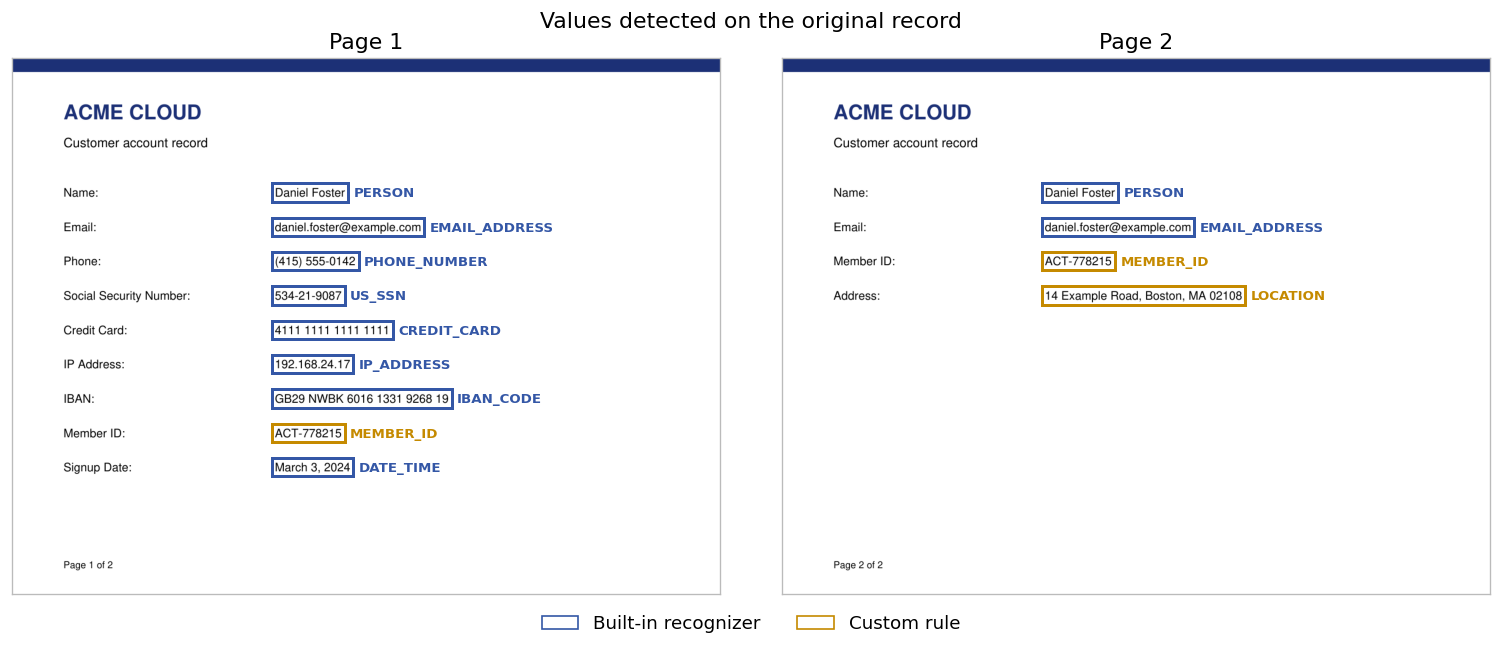

In [7]:
def show_page(ax, page, title):
    """Draw a PDF page in PDF coordinates, so PyMuPDF boxes can be plotted on top of it."""
    pix = page.get_pixmap(dpi=150)
    image = np.frombuffer(pix.samples, dtype=np.uint8).reshape(pix.height, pix.width, pix.n)
    ax.imshow(image, extent=(0, page.rect.width, page.rect.height, 0))
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set(visible=True, color="#BBBBBB")


CUSTOM = {"MemberIdRecognizer", "AddressRecognizer"}

fig, axes = plt.subplots(1, 2, figsize=(13, 5.4))
with pymupdf.open(ORIGINAL_PDF) as doc:
    for ax, page in zip(axes, doc):
        show_page(ax, page, f"Page {page.number + 1}")

for d in detections:
    colour = GOLD if d["recognizer"] in CUSTOM else BLUE
    ax = axes[d["page"] - 1]
    for box in d["boxes"]:
        ax.add_patch(Rectangle((box.x0 - 3, box.y0 - 1), box.width + 6, box.height + 2,
                               fill=False, edgecolor=colour, linewidth=1.8))
        ax.text(box.x1 + 8, box.y1 - 4, d["entity"], color=colour, fontsize=8, fontweight="bold")

fig.suptitle("Values detected on the original record")
fig.legend(handles=[Patch(fill=False, edgecolor=BLUE, label="Built-in recognizer"),
                    Patch(fill=False, edgecolor=GOLD, label="Custom rule")],
           loc="lower center", ncol=2, frameon=False)
fig.tight_layout(rect=(0, 0.05, 1, 1))
plt.show()

## 4. Consistent fake values

Faker makes a replacement of the same type for each distinct value. We store them in a dictionary,
so a value that appears twice gets the same replacement both times.

In [8]:
fake = Faker("en_US")
fake.seed_instance(41)


def in_groups_of_4(code):
    return " ".join(code[i:i + 4] for i in range(0, len(code), 4))


def fake_date():
    day = fake.date_between(date(2010, 1, 1), date(2025, 1, 1))
    return f"{day:%B} {day.day}, {day.year}"  # same style as "March 3, 2024"


def fake_address():
    return f"{fake.street_address()}, {fake.city()}, {fake.state_abbr()} {fake.postcode()}"


# One generator per entity type. Where a range is reserved for examples, we use it,
# so a fake can never reach a real inbox, phone or server.
fake_value = {
    "PERSON": fake.name,
    "EMAIL_ADDRESS": fake.ascii_safe_email,  # example.com, example.org, example.net
    "PHONE_NUMBER": lambda: fake.numerify("(202) 555-01##"),  # 555-0100 to 555-0199
    "US_SSN": fake.ssn,
    "CREDIT_CARD": lambda: in_groups_of_4(fake.credit_card_number(card_type="visa")),
    "IP_ADDRESS": lambda: f"192.0.2.{fake.random_int(1, 254)}",  # 192.0.2.0/24
    "IBAN_CODE": lambda: in_groups_of_4(fake.iban()),
    "MEMBER_ID": lambda: fake.numerify("ACT-######"),
    "DATE_TIME": fake_date,
    "LOCATION": fake_address,
}

replacements = {}
for d in detections:
    if d["value"] not in replacements:
        replacements[d["value"]] = fake_value[d["entity"]]()

found = pd.DataFrame(detections)
found["replacement"] = found["value"].map(replacements)
mapping = found.groupby(["entity", "value", "replacement"], sort=False).agg(pages=("page", list))
mapping.reset_index()

,entity,value,replacement,pages
0,PERSON,Daniel Foster,David Martin,"[1, 2]"
1,EMAIL_ADDRESS,daniel.foster@example.com,slane@example.com,"[1, 2]"
2,PHONE_NUMBER,(415) 555-0142,(202) 555-0184,[1]
3,US_SSN,534-21-9087,393-94-9445,[1]
4,CREDIT_CARD,4111 1111 1111 1111,4307 2252 4990 1906,[1]
5,IP_ADDRESS,192.168.24.17,192.0.2.111,[1]
6,IBAN_CODE,GB29 NWBK 6016 1331 9268 19,GB95 JXGC 5728 0112 2045 39,[1]
7,MEMBER_ID,ACT-778215,ACT-099260,"[1, 2]"
8,DATE_TIME,"March 3, 2024","July 10, 2014",[1]
9,LOCATION,"14 Example Road, Boston, MA 02108","16076 Andrew Dale, South Sonyafurt, NE 70271",[2]


The name, email and member ID appear on both pages and get the same fake each time.

The `replacements` dictionary works like the key in tokenization: whoever holds it can put the real
values back. While it exists, the output is **pseudonymized, not anonymized**, and it is still
personal data. Deleting the key removes that route, but whether the result is anonymous also
depends on what else in the document, or in other sources, could point to the person.

The seed is fixed only so reruns give the same fakes. In real use, leave it unset or keep it secret,
because the seed and the originals rebuild the same table.

## 5. Remove the originals and write the replacements

A white box drawn over a value only hides it. The text is still in the file and anyone can copy it
out. The next cell covers the name on page 1 with a white box and reads the text underneath.

In [9]:
with pymupdf.open(ORIGINAL_PDF) as doc:
    page = doc[0]
    box = page.search_for("Daniel Foster")[0]
    page.draw_rect(box, color=None, fill=(1, 1, 1))  # looks blank when printed or rendered
    print("Text under the white box:", repr(page.get_textbox(box)))

Text under the white box: 'Daniel Foster'


A redaction annotation marks an area, and `apply_redactions()` deletes the text under it from the
page. We then write each replacement on the original baseline, in a smaller font if it would run
past the right margin.

In [10]:
HELV = pymupdf.Font("helv")
RIGHT_EDGE = 660 - 48  # keep the same margin as on the left

with pymupdf.open(ORIGINAL_PDF) as doc:
    for page in doc:
        on_page = [d for d in detections if d["page"] == page.number + 1]
        for d in on_page:
            for box in d["boxes"]:
                page.add_redact_annot(box, fill=False)  # no fill: the text is deleted, not covered
        page.apply_redactions()

        for d in on_page:
            new = replacements[d["value"]]
            for box in d["boxes"]:
                # Shrink the font only if the fake would run past the margin
                width = HELV.text_length(new, FONT_SIZE)
                size = min(FONT_SIZE, FONT_SIZE * (RIGHT_EDGE - box.x0) / width)
                # The box reaches below the baseline by the font's descender
                baseline = (box.x0, box.y1 + HELV.descender * FONT_SIZE)
                page.insert_text(baseline, new, fontsize=size)

    # Metadata can carry names (here the title does), so clear it too
    doc.set_metadata({})
    doc.del_xml_metadata()
    # Without garbage=4 the old page content stays in the file as unused objects,
    # and the removed text could still be read from there
    doc.save(REPLACED_PDF, garbage=4, deflate=True, clean=True)

print(f"Replaced {len(detections)} values ({len(replacements)} distinct) on {len(PAGES)} pages")
print("Saved", REPLACED_PDF)

Replaced 13 values (10 distinct) on 2 pages
Saved generated/01_document_anonymization/record_replaced.pdf


## 6. Check the new file

We reopen the saved PDF and search its text for every value we put into the form. That list should be
empty. The header, the field labels and the page size should not change. This reads the visible
page text. The old page content that still held the originals was dropped by `garbage=4` above.

In [11]:
original_values = list(dict.fromkeys(value for fields in PAGES for _, value in fields))
labels = [label + ":" for fields in PAGES for label, _ in fields]
should_stay = ["ACME CLOUD", "Customer account record"] + labels

with pymupdf.open(ORIGINAL_PDF) as before, pymupdf.open(REPLACED_PDF) as after:
    new_text = "".join(page.get_text() for page in after)
    print("Original values still in the text:", [v for v in original_values if v in new_text])
    print("Header or labels missing:         ", [t for t in should_stay if t not in new_text])
    print("Page sizes before:", [page.rect for page in before])
    print("Page sizes after: ", [page.rect for page in after])
    print("Title before:", repr(before.metadata["title"]))
    print("Title after: ", repr(after.metadata["title"]))

Original values still in the text: []
Header or labels missing:          []
Page sizes before: [Rect(0.0, 0.0, 660.0, 500.0), Rect(0.0, 0.0, 660.0, 500.0)]
Page sizes after:  [Rect(0.0, 0.0, 660.0, 500.0), Rect(0.0, 0.0, 660.0, 500.0)]
Title before: 'Account record for Daniel Foster'
Title after:  ''


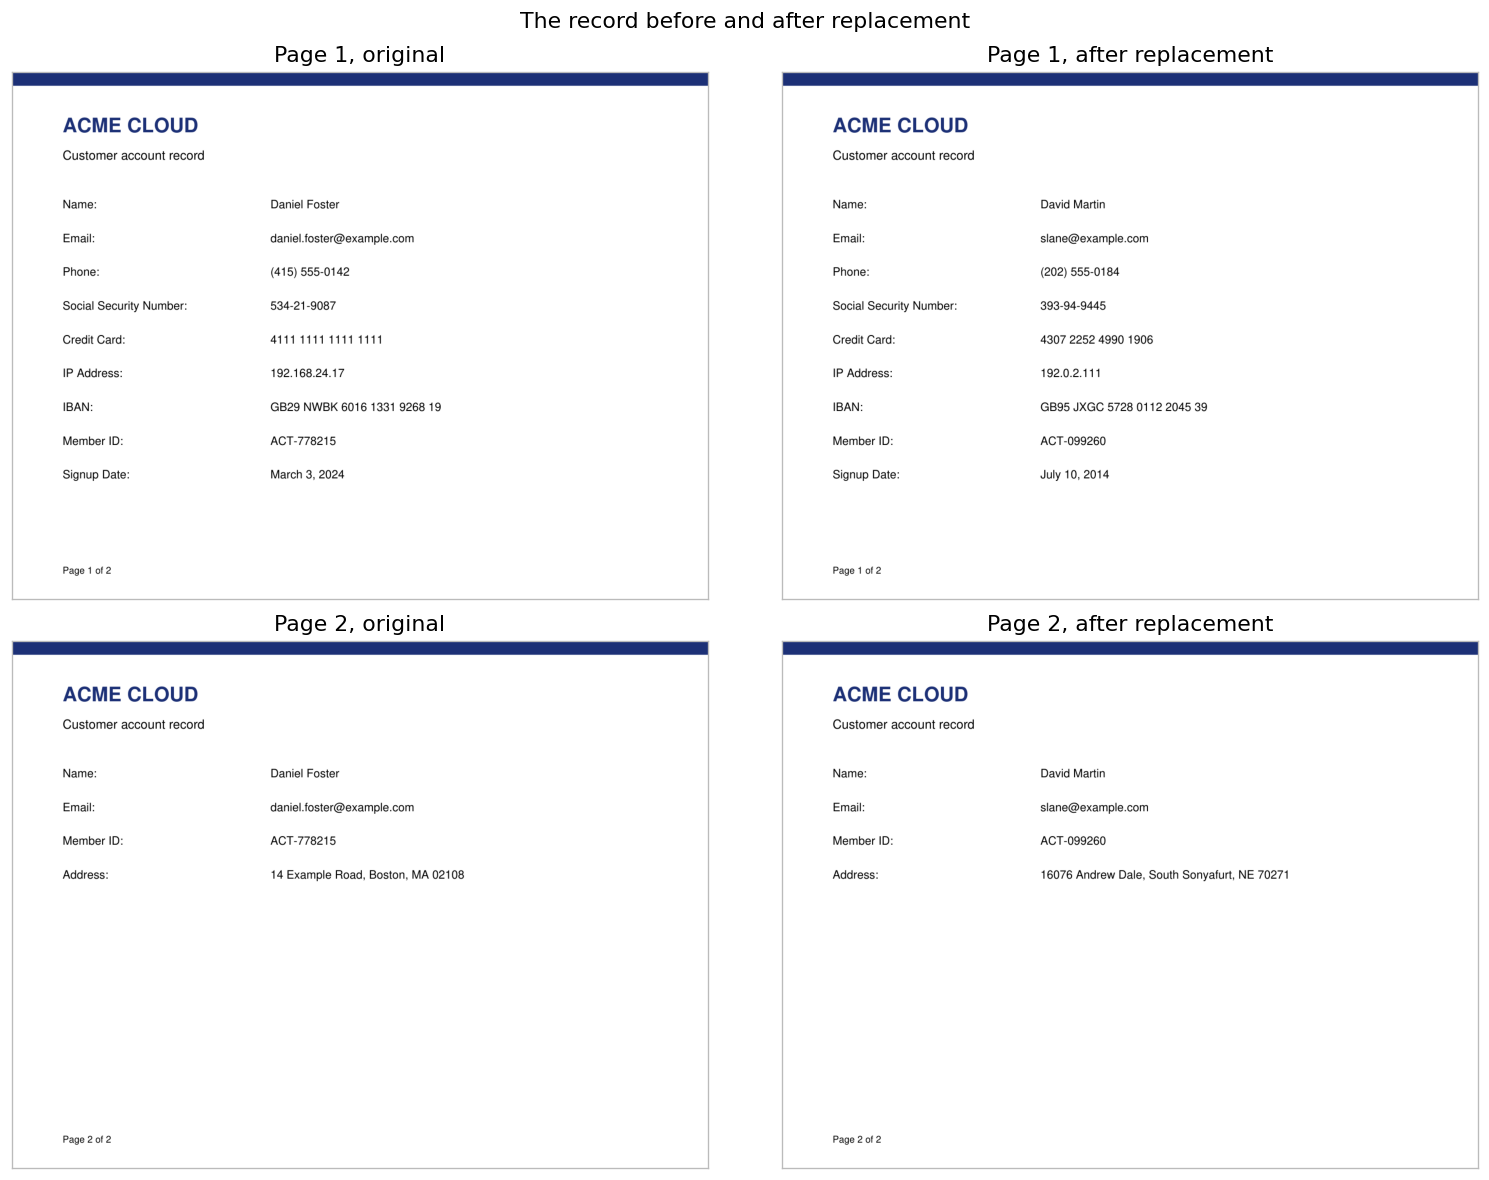

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
with pymupdf.open(ORIGINAL_PDF) as before, pymupdf.open(REPLACED_PDF) as after:
    for i in range(len(PAGES)):
        show_page(axes[i, 0], before[i], f"Page {i + 1}, original")
        show_page(axes[i, 1], after[i], f"Page {i + 1}, after replacement")
fig.suptitle("The record before and after replacement")
fig.tight_layout()
plt.show()

The layout and labels are unchanged, and the same fake customer appears on both pages. The output is
only as good as the detection: a value that no recognizer finds stays in the file. So on a new kind
of form, open a sample of the output files and read them before you share them.

## Experiments

1. Skip the two `add_recognizer` lines in section 3 and run all cells again. Which values does the
   check in section 6 report now? Look at the address on page 2 as well.
2. Replace every value with its entity type in brackets, such as `[PERSON]`, instead of a Faker value.
   This is masking. What can a reader of the document still do, and what not?
3. Add a field such as `("Licence Plate", "7ABC123")` to page 2. Does any recognizer find it? Write a
   pattern for it and use `fake.license_plate` as its generator.

**References:** [PyMuPDF redactions](https://pymupdf.readthedocs.io/en/latest/page.html#Page.apply_redactions) ·
[Presidio analyzer](https://microsoft.github.io/presidio/analyzer/) ·
[Presidio custom recognizers](https://microsoft.github.io/presidio/analyzer/adding_recognizers/) ·
[Faker](https://faker.readthedocs.io/)